In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [34]:
df = pd.read_csv("../data/data_with_indicators.csv", parse_dates=["Date"])
print(df.shape)
print(df.head())

(37903, 18)
        Date   Open   High    Low  Close    Volume ticker     EMA_20  \
0 2016-03-16  70.39  70.68  69.86  70.00   5769400   ALRS  69.684189   
1 2016-03-17  70.99  71.60  70.25  71.00   7833000   ALRS  69.809504   
2 2016-03-18  71.25  71.50  70.13  70.17  13063700   ALRS  69.843837   
3 2016-03-21  70.30  71.35  69.87  71.06  24094200   ALRS  69.959662   
4 2016-03-22  71.19  71.85  70.31  70.85  38485600   ALRS  70.044456   

      EMA_50      MACD  MACD_signal  MACD_diff        RSI    BB_high  \
0  65.813319  1.586659     2.125754  -0.539095  56.156848  72.757579   
1  66.016718  1.511851     2.002973  -0.491122  60.054941  72.779006   
2  66.179592  1.369800     1.876339  -0.506538  55.633635  72.642910   
3  66.370981  1.313894     1.763850  -0.449955  59.109927  72.555319   
4  66.546629  1.238368     1.658753  -0.420385  57.956009  72.488269   

      BB_low   BB_mid  BB_width   Volume_MA  
0  68.051421  70.4045  6.684455   9139020.0  
1  68.229994  70.5045  6.45208

In [35]:
def create_labels(df, horizon, threshold=0.03):
    """
    horizon   — через сколько дней смотрим вперёд
    threshold — порог 3% = 0.03
    """
    future_return = df["Close"].shift(-horizon) / df["Close"] - 1

    labels = np.where(future_return > threshold, 1,
             np.where(future_return < -threshold, -1, 0))

    return labels

In [36]:
horizons = [3, 5, 10, 30, 90, 365]

for h in horizons:
    df[f"target_{h}d"] = (
        df.groupby("ticker", group_keys=False)
        .apply(lambda x: pd.Series(create_labels(x, horizon=h), index=x.index))
    )

print(df[["ticker", "Date", "Close", "target_3d", "target_5d", "target_10d", "target_30d", "target_90d", "target_365d"]].head(20))

   ticker       Date  Close  target_3d  target_5d  target_10d  target_30d  \
0    ALRS 2016-03-16  70.00          0          0           0           1   
1    ALRS 2016-03-17  71.00          0          0           0           1   
2    ALRS 2016-03-18  70.17          0          0           0           1   
3    ALRS 2016-03-21  71.06          0          0           0           1   
4    ALRS 2016-03-22  70.85          0          0           0           0   
5    ALRS 2016-03-23  71.20         -1          0           0           0   
6    ALRS 2016-03-24  70.68          0          0           0           0   
7    ALRS 2016-03-25  70.36          0          0           0           1   
8    ALRS 2016-03-28  68.93          0          0           1           1   
9    ALRS 2016-03-29  69.24          0          0           1           1   
10   ALRS 2016-03-30  70.00          0          0           0           1   
11   ALRS 2016-03-31  69.60          0          0           0           1   

C:\Users\meteo\AppData\Local\Temp\ipykernel_43644\1194889965.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series(create_labels(x, horizon=h), index=x.index))
C:\Users\meteo\AppData\Local\Temp\ipykernel_43644\1194889965.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series(create_labels(x, horizon=h), index=x.index))
C:\Users\meteo\AppData\Local\Temp\ipyker

In [37]:
for h in horizons:
    col = f"target_{h}d"
    counts = df[col].value_counts().sort_index()
    pct = (counts / len(df) * 100).round(1)

    print(f"\nГоризонт {h} дней:")
    print(f"  Продавать (-1): {counts[-1]:>6} ({pct[-1]}%)")
    print(f"  Держать    (0): {counts[0]:>6} ({pct[0]}%)")
    print(f"  Покупать   (1): {counts[1]:>6} ({pct[1]}%)")


Горизонт 3 дней:
  Продавать (-1):   4623 (12.2%)
  Держать    (0):  28020 (73.9%)
  Покупать   (1):   5260 (13.9%)

Горизонт 5 дней:
  Продавать (-1):   6601 (17.4%)
  Держать    (0):  23777 (62.7%)
  Покупать   (1):   7525 (19.9%)

Горизонт 10 дней:
  Продавать (-1):   9237 (24.4%)
  Держать    (0):  17976 (47.4%)
  Покупать   (1):  10690 (28.2%)

Горизонт 30 дней:
  Продавать (-1):  12693 (33.5%)
  Держать    (0):  10375 (27.4%)
  Покупать   (1):  14835 (39.1%)

Горизонт 90 дней:
  Продавать (-1):  13791 (36.4%)
  Держать    (0):   6749 (17.8%)
  Покупать   (1):  17363 (45.8%)

Горизонт 365 дней:
  Продавать (-1):  13955 (36.8%)
  Держать    (0):   7538 (19.9%)
  Покупать   (1):  16410 (43.3%)


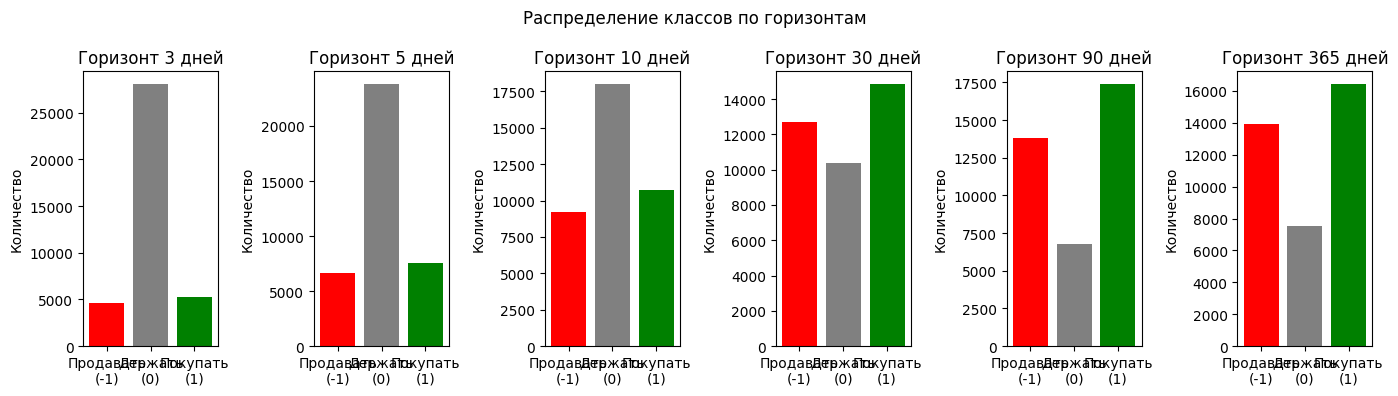

In [38]:
fig, axes = plt.subplots(1, 6, figsize=(14, 4))

for i, h in enumerate(horizons):
    col = f"target_{h}d"
    counts = df[col].value_counts().sort_index()
    axes[i].bar(
        ["Продавать\n(-1)", "Держать\n(0)", "Покупать\n(1)"],
        counts.values,
        color=["red", "gray", "green"]
    )
    axes[i].set_title(f"Горизонт {h} дней")
    axes[i].set_ylabel("Количество")

plt.suptitle("Распределение классов по горизонтам")
plt.tight_layout()
plt.show()

In [39]:
# Убираем последние строки где future цены недоступны
df = df.dropna(subset=["target_3d", "target_5d", "target_10d"])

# Приводим метки к int
for h in horizons:
    df[f"target_{h}d"] = df[f"target_{h}d"].astype(int)

df.to_csv("../data/data_labeled.csv", index=False)
print(f"Сохранено! Строк: {len(df)}, Колонок: {len(df.columns)}")

Сохранено! Строк: 37903, Колонок: 24
